## MINI PROJET PYTHON SUR L'ANALYSE DE LA QUALITE DE L'AIR

##### **NDEYE BAKHOUM** MASTER 1 ECONOMIE DE LA SANTE

L'objectif est de mettre en pratique les différentes notions nécessaire pour explorer, analyser et interpréter des données. Nous allons utliser les libraries de base necessaire pour une analyse à savoir **Pandas**, **Numpy**, **seaborn** et **Matplotlib**.

In [1]:
# import des librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### I. Chargement et Exploration

#### 1. Charger le fichier CSV dans un Dataframe

In [2]:
# Import de la base de données

airq = pd.read_csv("air_quality.csv", sep = ',' ) 
airq.shape

(999, 6)

Pour importer notre base de données, nous avons utiliser la fonction **read_csv()** implantée dans la librairie **Pandas**. La fonction shape nous permet de connaitre la dimension de notre base qui comprend ici 999 observations et 6 variables.

#### 2. Afficher les premières lignes et les types de données

In [3]:
# Affichons les dix premiers observations

airq.head(10)

,date,city,PM2.5,PM10,NO2,O3
0,2023-01-01 00:00:00,Paris,29.967142,37.926035,37.772262,32.184239
1,2023-01-01 01:00:00,Paris,NaN,36.487946,48.950554,26.139478
2,2023-01-01 02:00:00,Paris,20.305256,48.138401,24.438988,16.274162
3,2023-01-01 03:00:00,Paris,27.419623,11.300796,9.300986,15.501700
4,2023-01-01 04:00:00,Paris,14.871689,44.713710,NaN,NaN
5,2023-01-01 05:00:00,Paris,NaN,36.613355,30.810338,8.602015
6,2023-01-01 06:00:00,Paris,19.556173,41.663839,16.188077,23.005584
7,2023-01-01 07:00:00,Paris,18.993613,35.624594,22.779521,34.818225
8,2023-01-01 08:00:00,Paris,24.865028,24.134336,39.870539,10.233251
9,2023-01-01 09:00:00,Paris,27.088636,10.604948,14.061767,21.574890


Notre Base de données comprend six variables à savoir :
- Date : horodatage des mesures en heure
- City : nom de la ville (Paris, Marseille et Lyon
- Les variables PM2.5, PM10, NO2 et O3 : concentation horaire des principaux polluants

In [4]:
# Informations sur le type de variables

airq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    999 non-null    object 
 1   city    999 non-null    object 
 2   PM2.5   953 non-null    float64
 3   PM10    955 non-null    float64
 4   NO2     944 non-null    float64
 5   O3      947 non-null    float64
dtypes: float64(4), object(2)
memory usage: 47.0+ KB


En utilisant les fonction **info()** ou **dtypes**, nous pouvons avoir des informations concernant le type de variables que nous avons.Nous constatons ainsi que certaines de nos variables présentent des valeurs manquantes. Il s'agit principalement des variables concernant le type de polluant.

#### 3. Statistiques descriptives par polluant

In [5]:
# Statistiques descriptives par polluant

airq.describe()

,PM2.5,PM10,NO2,O3
count,953.000000,955.000000,944.000000,947.000000
mean,27.050614,43.499605,32.133915,21.566367
std,18.235973,26.777697,22.369111,13.607651
min,-5.195122,-3.443831,-8.895208,-3.929088
25%,18.872113,30.673397,21.761581,14.675820
50%,25.644744,41.099770,30.089660,20.375479
75%,31.791428,51.400014,38.061502,25.912568
max,226.873783,366.882804,287.194636,188.767550


Nous utilisons la fonction **describe()** afin de determiner les statistiques descriptives des différents polluants. Nous pouvons noter que parmi ces dernières, c'est la pollution de particules inhalables **PM10** qui emet le plus de pollution.En effet on note qu'il a une concentration horaire moyenne plus élevé par rapport au autres (43.499 μg/m³). 

### II. Valeurs manquantes

#### 1. Valeurs manquantes par colonne 

In [6]:
# Determinons les valeurs manquantes par variable

airq.isna().sum()

date      0
city      0
PM2.5    46
PM10     44
NO2      55
O3       52
dtype: int64

On utilise la fonction **isna()** et **sum()** pour identifier les données manquantes. Nous pouvons constater que certaines de nos variables présentent des valeurs manquantes; il sagit principalement des différents polluants. Chacune comportant au moins 40 valeurs manquantes.

#### 2. Visualisation des valeurs manquantes pour chaque polluant

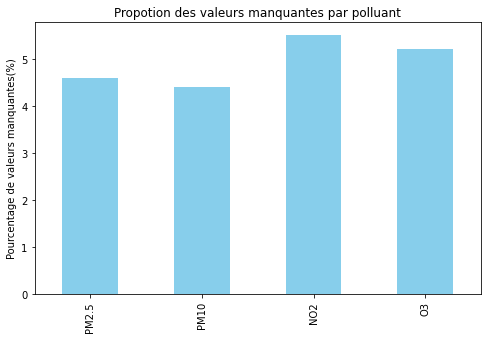

In [7]:
# Calcul de la proportion de valeurs manquantes

valeur_manquante = airq.isnull().mean()*100
valeur_manquante_polluant = valeur_manquante[valeur_manquante > 0]

# Affichons ces proportions dans un Barplot

plt.figure(figsize=(8,5))
valeur_manquante_polluant.plot(kind = 'bar' , color = 'skyblue')
plt.ylabel("Pourcentage de valeurs manquantes(%)")
plt.title("Propotion des valeurs manquantes par polluant")
plt.show()

La pollution de dioxyde d'azote **NO2** et d'ozone troposphérique **O3** presentent le plus valeurs manquantes.

#### 3. Analyse de la répartion des valeurs manquantes par ville

In [8]:
# La répartition des valeurs manquantes par ville

airq.groupby('city')[['PM2.5', 'PM10', 'NO2', 'O3']].apply(lambda x: x.isnull().sum())

,PM2.5,PM10,NO2,O3
city,,,,
Lyon,13,14,16,16
Marseille,15,17,22,18
Paris,18,13,17,18


Les valeurs manquantes sont réparties inéquitablement entre les différentes villes. On notera plus de valeurs manquantes dans la ville de Marseille par rapport aux autres villes Paris et Lyon. 

### III. Interpolation

In [9]:
# Conversion de la variale date en datetime

airq['date'] = pd.to_datetime(airq['date'])
airq.dtypes

date     datetime64[ns]
city             object
PM2.5           float64
PM10            float64
NO2             float64
O3              float64
dtype: object

In [10]:
# Appliquons une interpolation lineaire temporelle pour combler les valeurs manquantes

airq1 = airq.set_index('date')
airq2 = airq1.interpolate(method = 'time')

In [11]:
airq2.isna().sum()

city     0
PM2.5    0
PM10     0
NO2      0
O3       0
dtype: int64

Pour combler nos valeurs manquantes, nous avons fait une interpolation lineaire sur la variable date. Pour ce faire nous 
convertisons d'abord notre variable **date** qui n'est pas au format datetime en utilisant la fonction **to_datetime** implanté dans **pandas**. Ensuite nous fesons une interpolation lineaire sur cette dernière. Nous pouvons oberver que tous nos valeurs manquantes ont été imputées.

### IV. Outliers

#### 1. Méthode de l'IQR pour détecter les valeurs extrêmes

In [12]:
# Utilisons la méthode de l'IQR pour détecter les outliers

def detect_outlier(data):
    
    variable_numeric = data.select_dtypes(include=['float64']).columns
    outlier_variable = {}

    
    for i in variable_numeric:
        Q1 = data[i].quantile(0.25)
        Q3 = data[i].quantile(0.75)
        IQR = Q3 - Q1
        
        binf = Q1 - 1.5 * IQR
        bsup = Q3 + 1.5 * IQR
    
        outlier = data[(data[i] < binf) | (data[i] > bsup)]
        outlier_variable[i] = len(outlier)

    return pd.DataFrame(list(outlier_variable.items()), columns = ['variable', 'Nombre_outliers']) 

In [13]:
outlier_aiq2 = detect_outlier(airq2)
outlier_aiq2

,variable,Nombre_outliers
0,PM2.5,22
1,PM10,29
2,NO2,24
3,O3,22


Nous avons détecter les outliers ou valeurs extrêmes en utilisant la méthode **IQR**(InterQuartile Range). Il consiste à calculer les 1er(Q1) et 3ème quartile(Q3) puis on calcule l'ecart interquartile(IQR). Ces derniers vont nous permettre de définir un intervalle et toutes valeurs qui ne se trouveras pas dans celle-ci sera considéré comme un outlier. Nous avons défini tout cela sur une fonction dénommée **detect_outlier** pour simplifier la démarche. 
Nous constatons que les variables de pollution contiennent tous au moins 20 outliers.

#### 2. Imputation des outliers par la médiane

In [14]:
# Creons un fonction pour imputer les outliers par la mediane

def impute_mediane(df,col):
    
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
    
        binf = Q1 - 1.5 * IQR
        bsup = Q3 + 1.5 * IQR
    
        median = df[col].median()   
        df.loc[(df[col] < binf) | (df[col] > bsup), col] = median
        
        return df

In [21]:
# Utilisation de la fonction sur nos variables

var = ['PM2.5', 'PM10', 'NO2', 'O3']

for col in var:
    airq3 = impute_mediane(airq2, col)       

In [22]:
outlier_airq3 = detect_outlier(airq3)
outlier_airq3

,variable,Nombre_outliers
0,PM2.5,0
1,PM10,0
2,NO2,0
3,O3,0


Pour gérer nos outliers, nous avons utiliser la méthode de l'imputation par la médiane. Pour ce faire une fonction **imput_mediane** a été crée définissant les bornes supérieures et inférieures mais aussi calculant la médiane pour chaque variable et remplacer nos outliers par cette médiane. Aprés avoir utliser la fonction sur nos variables, nous pouvons constater que nos variables ne contiennent plus d'outliers.

### V. Visualisation et Analyse

#### 1. Boxplot des variables de pollution

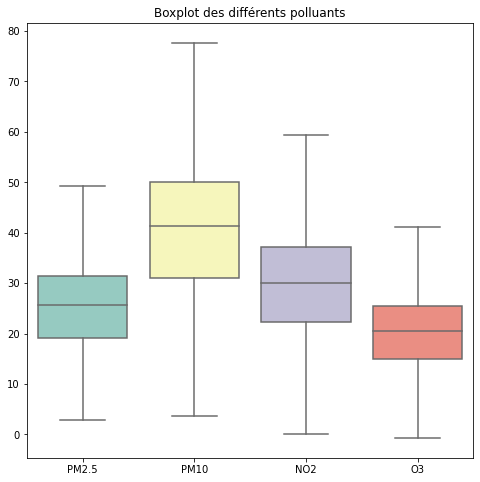

In [23]:
# On ne retient que les différents polluants

polluants = airq3[['PM2.5', 'PM10', 'NO2', 'O3']]

# On trace le boxplot des différents polluants

plt.figure(figsize=(8, 8))
sns.boxplot(data=polluants, palette='Set3')
plt.title('Boxplot des différents polluants')
plt.show()

Les boxplots de chaque polluant ont été tracé à l'aide de la fonction **boxplot** implanté dans la librairie **seaborn**. Les boxplots permettent de mettre en évidence les statistiques d'une variable quantitative à savoir la médiane, les minimum et maximum de même que les 1er et 3ème quartile. Nous pouvons aussi observé les valeurs extrêmes. 

#### 2. Courbes temporelles avec moyenne mobile (24h) pour PM2.5 à Paris

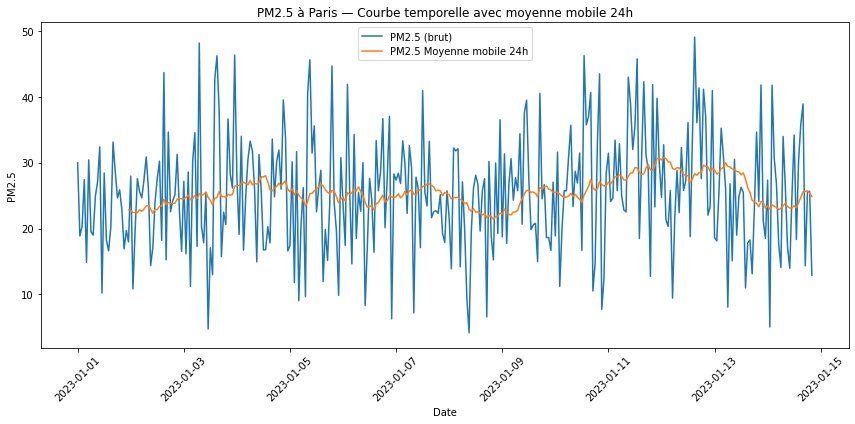

In [24]:
# On filtre nos données sur la ville de Paris

airq_paris = airq3[airq3['city'] == 'Paris'].copy()

# On calcul ensuite la moyenne mobile

airq_paris['MM24'] = airq_paris['PM2.5'].rolling(window=24).mean()

# On trace les courbes de moyenne mobile(24h) pour le polluant PM2.5

plt.figure(figsize=(12,6))
plt.plot(airq_paris.index, airq_paris['PM2.5'], label='PM2.5 (brut)')
plt.plot(airq_paris.index, airq_paris['MM24'], label='PM2.5 Moyenne mobile 24h')
plt.title('PM2.5 à Paris — Courbe temporelle avec moyenne mobile 24h')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La courbe de la moyenne mobile sur 24h permet de mettre en évidence la tendance. La courbe des données brutes nous montre beaucoup fluctuations de ce fait nous ne pouvons pas oberver la tendance. Avec la moyenne mobile, la pollution PM2.5 reste relativement stable, nous avons ni une tendance en hausse ni en baisse. Donc la pollution de type PM2.5 à Paris reste stable sur la période observée.

#### 3. Matrice de corrélation entre les polluants

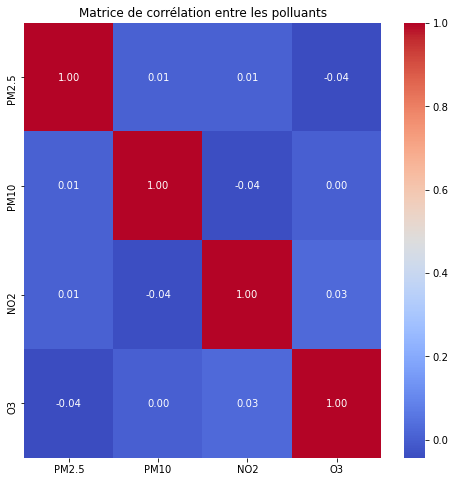

In [25]:
# Calculer et afficher une matrice de corrélation entre les polluants.

# On ne retient que les différents polluants

polluants = airq3[['PM2.5', 'PM10', 'NO2', 'O3']]

# On calcul les coefficients de corrélation entre les polluants

cor = polluants.corr()

# On trace le boxplot des différents polluants

plt.figure(figsize=(8, 8))
sns.heatmap(cor, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation entre les polluants")
plt.show()

La matrice de corrélation permet d'identifier les coéfficents de corrélation entre des varaibles numériques.Nous pouvons remarquer une trés faible corrélation entre les polluants limite nulle. Autrement dit il n'y a pas de relation lineaire forte entre les polluants. On note que le coéfficient de corrélation entre l'ozone(**O3**) et la pollution au particules fines(**PM2.5**) est négative donc il évolue de manière opposée à celle-ci. Par exemle une augmentation de la pollution au particules fines d'une unité entraine une diminution de l'ozone de 0.3 μg/m³. 

#### 4. La tendance de la pollution aux particules fines à Paris 

In [26]:
# Analyse de la tendance avec une régression lineaire

X = np.arange(len(airq_paris)).reshape(-1,1)
y = airq_paris["PM2.5"].values

model = LinearRegression()
model.fit(X, y)
slope = model.coef_[0]

print("Pente de la tendance :", slope)

Pente de la tendance : 0.007452704588667516


IL existe plusieurs manière pour déterminer la tendance d'une variable. On peut soit tracer la courbe temporelle avec moyenne mobile comme nous l'avons fait à la deuxième question, soit en calculant la pente de la droite de régression. Dans notre cas la pente de la droite de régession est trés proche de 0 donc on peut dire la pollution aux particules fines PM2.5 à Paris est assez stable. Ce qui confirme bien notre courbe temporelle avec moyenne mobile.